In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_excel("/content/Dirty_SaaS_Practice_Dataset_1000.xlsx")

df.head()
df.head(10)
df.tail()
rows,columns=df.shape

print("Rows:",rows)
print("Columns:",columns)

df.columns

df.info
df.describe()
df.describe(include='number')
df.describe(include='all')
df.describe(include='object')
df.dtypes
df.isnull().sum()

missing_percentage=pd.DataFrame({
    "Missing_values":df.isnull().sum(),
    "Misisng_Percentage":(df.isnull().sum()/len(df))*100
    })

missing_percentage

df.duplicated().sum()

df["CustomerID"].unique()

df["CustomerID"].nunique()

df["Plan"].value_counts()
df["Country"].value_counts()

df["Revenue"]

df.groupby("State").agg({'Revenue':'sum','DiscountPct':'mean'})

df[df["DiscountPct"]> 13]
df[df["Country"]== 'USA']
df[df["Plan"]=='Enterprise']

df[(df["Plan"]== 'Enterprise') & (df["PaymentMethod"]=="Bank")]
df[(df["Country"]== 'USA')|(df["CompanySize"]=="Large")]
df[
    df["Country"].isin(["USA","UK","Nigeria"])

]

df.sort_values(by="Revenue", ascending=False)

df.sort_values(by="Revenue",ascending=False).head(10)
df.nlargest(10,'Revenue')

df["Revenue"].max()
Lowest_Revenue = df.nsmallest(1, "Revenue")
print(Lowest_Revenue)

df.groupby("Country")["Revenue"].mean()
df.groupby("Country")["CustomerID"].count()

Country_analysis=df.groupby("Country").agg(
    customers=("CustomerID","count"),
    Total_revenue=('Revenue','sum'),
    Average_Revenue=('Revenue','mean')
)

print(Country_analysis)

Companysize_Analysis=df.groupby("CompanySize").agg(
    Total_customers=("CustomerID",'count'),
    Total_Revenue=('Revenue','mean'),
    Avg_DiscountPct=('DiscountPct','mean')
)

print(Companysize_Analysis)

industry_analysis=df.groupby('Industry').agg(
    Total_customers=('CustomerID','count'),
    Total_Revenue=('Revenue','sum'),
    Average_DiscountPct=('DiscountPct','mean')
).sort_values(by="Total_Revenue", ascending=False)

print(industry_analysis)

df["ChurnRisk"].value_counts()

df.groupby('ChurnRisk')["Revenue"].agg(['count','sum','mean'])

df.groupby("PaymentStatus")['Revenue'].sum()

Rows: 1000
Columns: 20
    CustomerID     Company Country    State   Plan BillingCycle  MonthlyPrice  \
17          18  Company 18      UK  England  Basic       Yearly         -50.0   

    DiscountPct  FinalPrice PaymentStatus PaymentMethod  SignupDate  \
17         10.0         NaN        Failed          Bank  04/10/2024   

    RenewalDate CompanySize Industry SupportTickets ChurnRisk  Revenue  \
17  Sep 29 2025       Large  Fintech           Five       Low      0.0   

                 Email       Phone  
17  user18@example.com  8065544016  
               customers  Total_revenue  Average_Revenue
Country                                                 
Canada               244       170286.5       697.895492
NIGERIA                7         2506.0       358.000000
Nigeria              246       173755.0       706.321138
U.S.                   5         6021.0      1204.200000
UK                   252       195135.5       774.347222
USA                  239       146050.5       611

,Revenue
PaymentStatus,
Failed,249509.5
Paid,235733.5
Pending,212884.5


In [4]:
df["SignupDate"]=pd.to_datetime(df["SignupDate"],errors="coerce")
df["RenewalDate"]=pd.to_datetime(df["RenewalDate"],errors="coerce")

df["RenewalDate"].dt.year
df["RenewalDate"].dt.month_name()
df["RenewalDate"].dt.day_name()


df["Phone"]=df["Phone"].astype(str)

In [5]:
df["Discount_amount"]=(df["MonthlyPrice"] * df["DiscountPct"])
df["Discount_amount"]=df["Discount_amount"].fillna(df["Discount_amount"].mean())

df["Discount_amount"]

,Discount_amount
0,800.000000
1,800.000000
2,0.000000
3,300.000000
4,544.979367
...,...
995,0.000000
996,300.000000
997,300.000000
998,544.979367


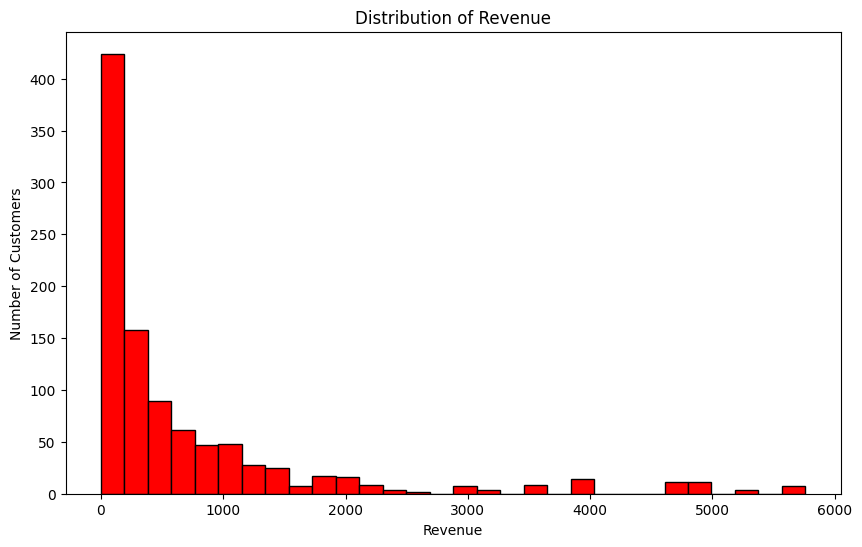

In [6]:
#BASIC VISUALIZATION
#1 Revenue Distribution

plt.figure(figsize=(10,6))

plt.hist(df['Revenue'].sort_values(ascending=False),bins=30,edgecolor='black',color='red')

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.show()

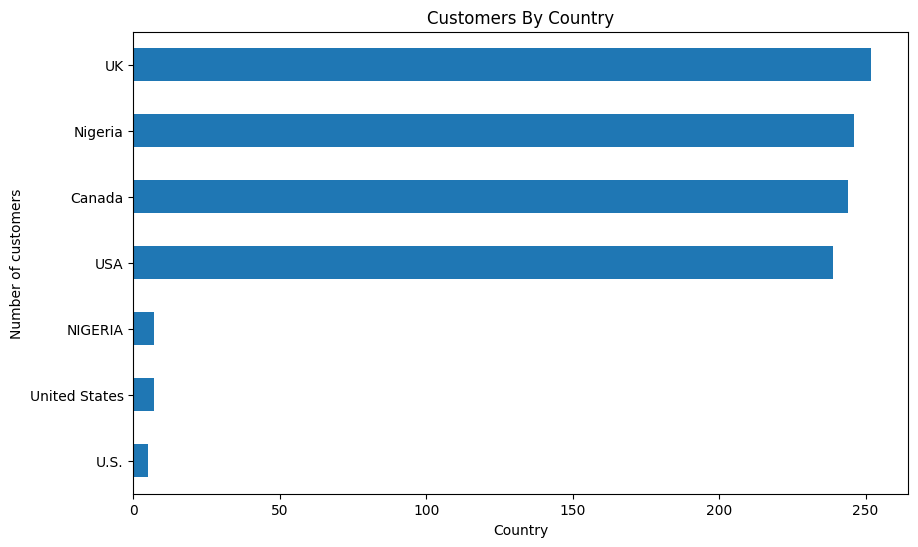

In [7]:
#Visualization 2: Customers by Country
df["Country"].value_counts(ascending=True).plot(kind='barh',figsize=(10,6))

plt.title("Customers By Country")
plt.xlabel('Country')
plt.ylabel("Number of customers")

plt.show()

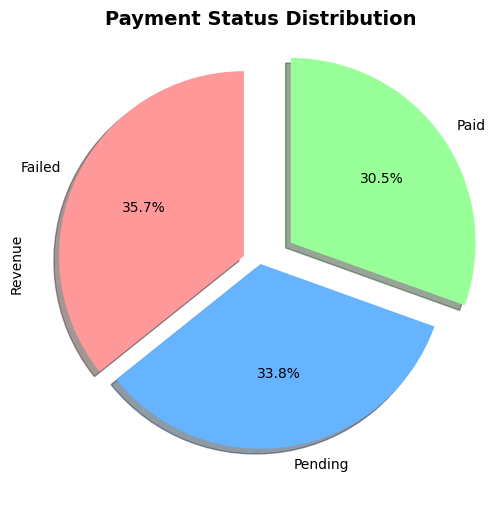

In [39]:
df.columns

#Payment Status Distribution
plt.figure(figsize=(10,6))
explode=[0.1,0,0.2]
colors= ['#ff9999', '#66b3ff', '#99ff99']
labels=["Failed","Pending","Paid"]

df.groupby("PaymentStatus")['Revenue'].sum().plot(kind='pie', startangle=90, shadow=True,colors=colors, explode=explode, autopct='%1.1f%%',labels=labels)
plt.title("Payment Status Distribution",fontsize=14,fontweight='bold')



plt.show()

In [9]:
data_quality_report=pd.DataFrame({
    "column":df.columns,
    "Data_type":df.dtypes.astype(str).values,
    "Missing_values":df.isnull().sum(),
    "Missing_percentage":(df.isnull().sum()/len(df))*100,
    "Unique_values":[df[column].nunique() for column in df.columns]
})

data_quality_report

,column,Data_type,Missing_values,Missing_percentage,Unique_values
CustomerID,CustomerID,int64,0,0.0,1000
Company,Company,object,0,0.0,1000
Country,Country,object,0,0.0,7
State,State,object,0,0.0,4
Plan,Plan,object,0,0.0,4
BillingCycle,BillingCycle,object,0,0.0,3
MonthlyPrice,MonthlyPrice,float64,29,2.9,4
DiscountPct,DiscountPct,float64,250,25.0,4
FinalPrice,FinalPrice,float64,75,7.5,26
PaymentStatus,PaymentStatus,object,0,0.0,3


In [10]:
df.columns

Index(['CustomerID', 'Company', 'Country', 'State', 'Plan', 'BillingCycle',
       'MonthlyPrice', 'DiscountPct', 'FinalPrice', 'PaymentStatus',
       'PaymentMethod', 'SignupDate', 'RenewalDate', 'CompanySize', 'Industry',
       'SupportTickets', 'ChurnRisk', 'Revenue', 'Email', 'Phone',
       'Discount_amount'],
      dtype='object')